In [ ]:
%load_ext autoreload
%autoreload 2
CUDA_VISIBLE_DEVICES=1

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import argparse
import torch

from tqdm.notebook import tqdm, trange

from models.classificaion_15_transformation_rules import (
    classificaion_15_transformation_rules,
    MyDataset,
    my_collate_fn,
    my_collate_fn_rationale,
    load_sst
)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--gpu", type=str, default="0")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument(
        "--val_filename",
        type=str,
        default="classificaion_15_transformation_rules/test_data/snli_1.0_dev_output.txt"
        
    )
    parser.add_argument(
        "--val_rationale",
        type=str,
        default="datasets/eSNLI/esnli_test.rationale_idx"
        
)
    parser.add_argument(
        "--model_path",
        type=str,
    
        default="outputs/ml_15rules_for_distribution_acc/epoch=14-val_acc=0.9637-val_f1=0.8513.ckpt"


    )
    parser.add_argument(
        "--dataset",
        type=str,
        default="coco", # coco, esnli
    )
    
    parser.add_argument("--token_cls", type=bool, default=False, help="Enable token classification")

    hparams, _ = parser.parse_known_args()
    
    torch.manual_seed(hparams.seed)
    
    os.environ["CUDA_VISIBLE_DEVICES"] = hparams.gpu

device = "cuda:0"

model = classificaion_15_transformation_rules.load_from_checkpoint(hparams.model_path).to(device)

model.freeze()
model.prepare_data()

In [ ]:
import pandas as pd


val_dataset, _ = load_sst(
    hparams.val_filename, None, hparams.dataset, model.hparams.num_labels, hparams.val_rationale, hparams.token_cls
)


filtered_dataset = []
skipped_count = 0

for data in val_dataset:
    label = data[1]  
    if isinstance(label, str) and label.strip() == '-':  
        skipped_count += 1
        continue
    filtered_dataset.append(data)  

print(f"Skipped rows with '-' label: {skipped_count}")


val_dataloader = torch.utils.data.DataLoader(
    filtered_dataset, batch_size=model.hparams.batch_size, collate_fn=my_collate_fn_rationale, num_workers=8
)

val_acc, num = [0]*19, [0]*19  
results = []

for i, batch in tqdm(enumerate(val_dataloader), total=len(filtered_dataset) // model.hparams.batch_size):
    inputs = model.tokenizer.batch_encode_plus(batch[0], pad_to_max_length=True, return_tensors='pt').to(device)
    input_ids = inputs['input_ids']
    mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']
    labels = batch[1].to(device)

    logits = model.forward(input_ids, mask, token_type_ids)[0]
    predictions = logits.argmax(-1)  

    for logit, label, sentence in zip(predictions, labels, batch[0]):
        val_acc[label] += (logit == label).int()
        num[label] += 1

        
        premise, hypothesis = sentence
        results.append({
            "Premise": premise,
            "Hypothesis": hypothesis,
            "Original Label": label.item(),
            "Predicted Label": logit.item()
        })


print(f"Overall Accuracy: {sum(val_acc) / sum(num)}")


results_df = pd.DataFrame(results)

label_idx = {
    'entailment_HS': 0, 'entailment_PS': 1, 'entailment_COUNT': 2, 'entailment_PA': 3, 'entailment_ES': 4,
    'contradiction_CW_adj': 5, 'contradiction_CW_noun': 6, 'contradiction_CV': 7, 'contradiction_NS': 8,
    'contradiction_SOS': 9, 'contradiction_IH': 10, 'contradiction_NI': 11,
    'neutral_AM': 12, 'neutral_CON': 13, 'neutral_SSNCV': 14, 'neutral_CA': 15, 'neutral_EI' : 16, 
            'entailment_RG': 17, 'neutral_VS' : 18
}

reverse_label_idx = {v: k for k, v in label_idx.items()}


results_df["Original Label"] = results_df["Original Label"].map(reverse_label_idx)
results_df["Predicted Label"] = results_df["Predicted Label"].map(reverse_label_idx)

output_file = "ml_outputs/devset_10000_15rules_distribution2.xlsx"
results_df.to_excel(output_file, index=False)

print(f"Results saved to {output_file}")


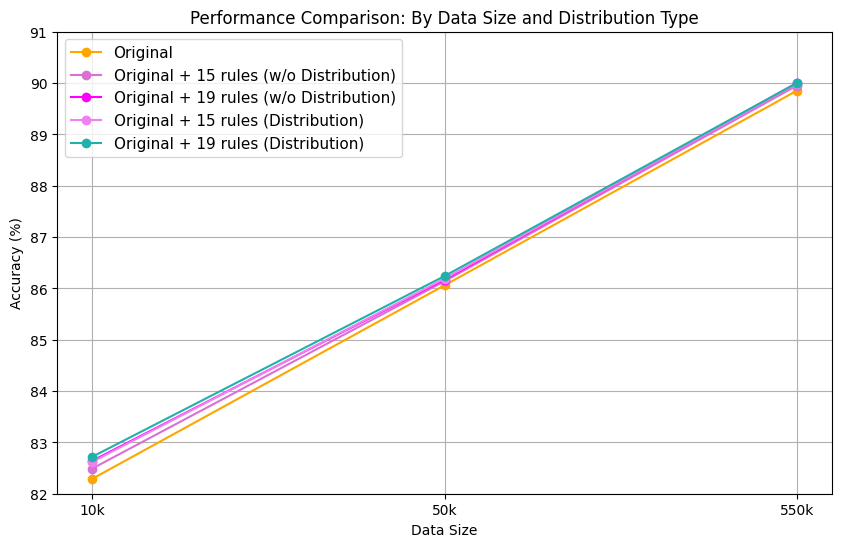

In [78]:
import matplotlib.pyplot as plt

# 데이터 준비
data_sizes = ['10k', '50k', '550k']
scenarios = ['Original', 'Original + 15 rules (w/o Distribution)',
             'Original + 19 rules (w/o Distribution)',
             'Original + 15 rules (Distribution)',
             'Original + 19 rules (Distribution)']

# 각 시나리오별 정확도 값
accuracy = {
    '10k': [82.29, 82.49, 82.64, 82.62, 82.72],
    '50k': [86.06, 86.14, 86.17, 86.19, 86.24],
    '550k': [89.85, 89.95, 90.00, 89.99, 90.00]
}

# 라인 차트 그리기
plt.figure(figsize=(10, 6))
colors = ['orange', 'orchid', 'fuchsia', 'violet', 'lightseagreen']  # 각 라인별 색상 지정
for scenario, color in zip(scenarios, colors):
    plt.plot(data_sizes, [accuracy[size][scenarios.index(scenario)] for size in data_sizes],
             marker='o', label=scenario, color=color)

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Data Size')
plt.ylabel('Accuracy (%)')
plt.ylim(82, 91)  # Y축 범위 조정
# plt.yticks(np.arange(82, 91, 0.5))  # Y축 틱 간격 0.5로 설정
plt.legend(title='', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.show()


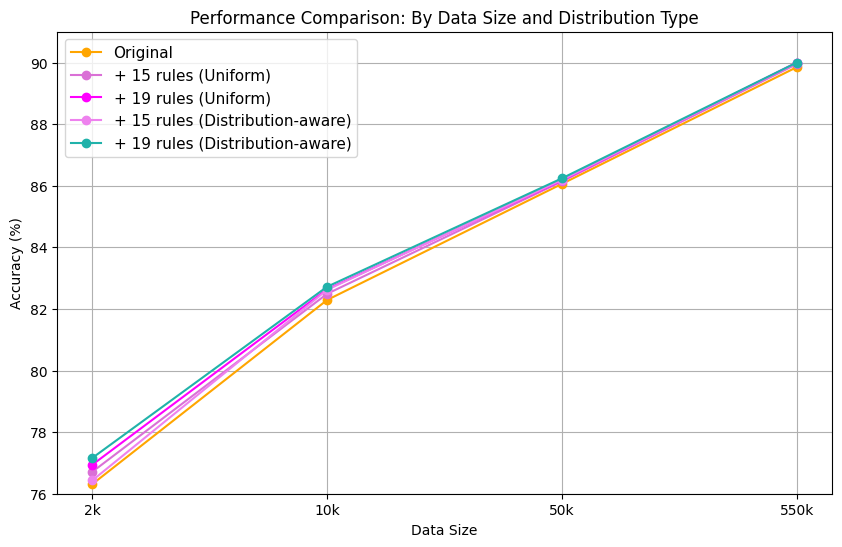

In [1]:
import matplotlib.pyplot as plt

# 데이터 준비
data_sizes = ['2k', '10k', '50k', '550k']
scenarios = ['Original', '+ 15 rules (Uniform)',
             '+ 19 rules (Uniform)',
             '+ 15 rules (Distribution-aware)',
             '+ 19 rules (Distribution-aware)']

# 각 시나리오별 정확도 값
accuracy = {
    '2k': [76.31, 76.71, 76.94, 76.43, 77.16],
    '10k': [82.29, 82.49, 82.64, 82.62, 82.72],
    '50k': [86.06, 86.14, 86.17, 86.19, 86.24],
    '550k': [89.85, 89.95, 90.00, 89.99, 90.00]
}

# 라인 차트 그리기
plt.figure(figsize=(10, 6))
colors = ['orange', 'orchid', 'fuchsia', 'violet', 'lightseagreen']  # 각 라인별 색상 지정
for scenario, color in zip(scenarios, colors):
    plt.plot(data_sizes, [accuracy[size][scenarios.index(scenario)] for size in data_sizes],
             marker='o', label=scenario, color=color)

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Data Size')
plt.ylabel('Accuracy (%)')
plt.ylim(76, 91)  # Y축 범위 조정
# plt.yticks(np.arange(82, 91, 0.5))  # Y축 틱 간격 0.5로 설정
plt.legend(title='', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.show()


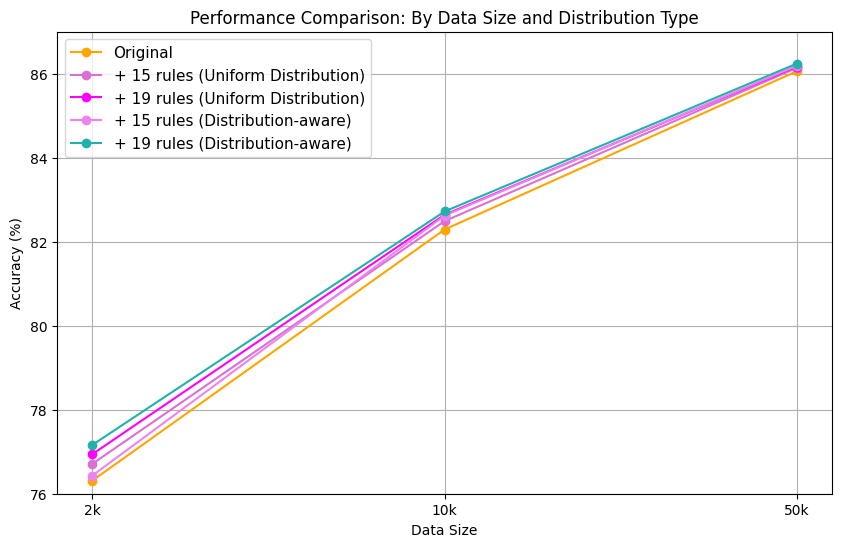

In [4]:
import matplotlib.pyplot as plt

# 데이터 준비
data_sizes = ['2k', '10k', '50k']

scenarios = ['Original', '+ 15 rules (Uniform Distribution)',
             '+ 19 rules (Uniform Distribution)',
             '+ 15 rules (Distribution-aware)',
             '+ 19 rules (Distribution-aware)']

# 각 시나리오별 정확도 값
accuracy = {
    '2k': [76.31, 76.71, 76.94, 76.43, 77.16],
    '10k': [82.29, 82.49, 82.64, 82.62, 82.72],
    '50k': [86.06, 86.14, 86.17, 86.19, 86.24],
}

# 라인 차트 그리기
plt.figure(figsize=(10, 6))
colors = ['orange', 'orchid', 'fuchsia', 'violet', 'lightseagreen']  # 각 라인별 색상 지정
for scenario, color in zip(scenarios, colors):
    plt.plot(data_sizes, [accuracy[size][scenarios.index(scenario)] for size in data_sizes],
             marker='o', label=scenario, color=color)

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Data Size')
plt.ylabel('Accuracy (%)')
plt.ylim(76, 87)  # Y축 범위 조정
# plt.yticks(np.arange(82, 91, 0.5))  # Y축 틱 간격 0.5로 설정
plt.legend(title='', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.show()


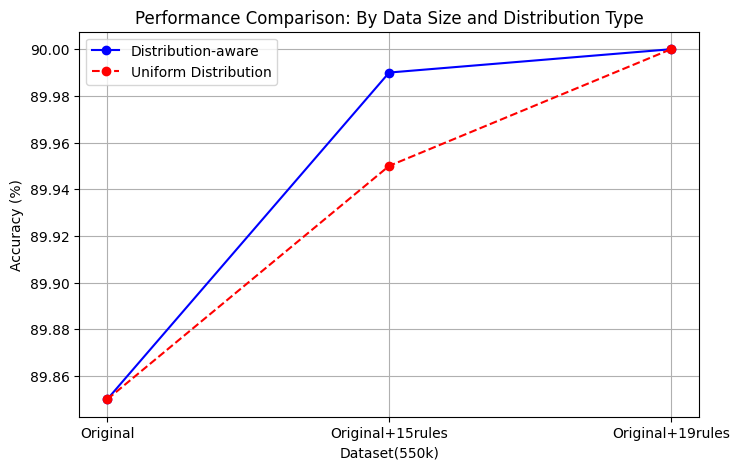

In [8]:
import matplotlib.pyplot as plt

# 55만개
# 성능 데이터 정의
categories = ['Original', 'Original+15rules', 'Original+19rules']
performance_X = [89.85, 89.95, 90.00]  # 분포X의 성능
performance_O = [89.85, 89.99, 90.00]  # 분포O의 성능

# 꺾은선 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(categories, performance_O, marker='o', label='Distribution-aware', linestyle='-', color='blue')
plt.plot(categories, performance_X, marker='o', label='Uniform Distribution', linestyle='--', color='red')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset(550k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


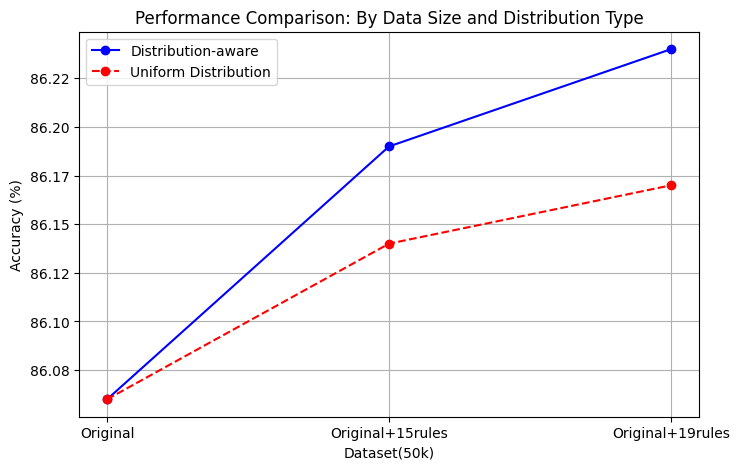

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 5만개
# 성능 데이터 정의
categories = ['Original', 'Original+15rules', 'Original+19rules']
performance_X = [86.06, 86.14, 86.17]  # 분포X의 성능
performance_O = [86.06, 86.19, 86.24]  # 분포O의 성능

# 꺾은선 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(categories, performance_O, marker='o', label='Distribution-aware', linestyle='-', color='blue')
plt.plot(categories, performance_X, marker='o', label='Uniform Distribution', linestyle='--', color='red')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset(50k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# y축 레이블 포맷 설정 (소수점 둘째자리까지)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.show()


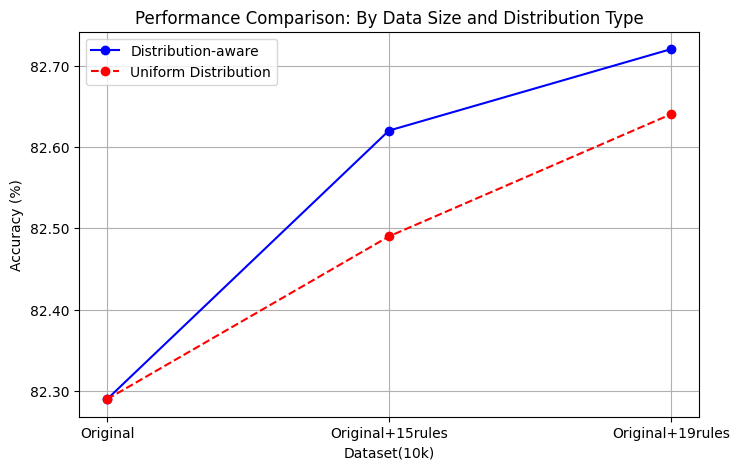

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 1만개
# 성능 데이터 정의
categories = ['Original', 'Original+15rules', 'Original+19rules']
performance_X = [82.29, 82.49, 82.64]  # 분포X의 성능
performance_O = [82.29, 82.62, 82.72]  # 분포O의 성능

# 꺾은선 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(categories, performance_O, marker='o', label='Distribution-aware', linestyle='-', color='blue')
plt.plot(categories, performance_X, marker='o', label='Uniform Distribution', linestyle='--', color='red')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset(10k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# y축 레이블 포맷 설정 (소수점 둘째자리까지)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.show()


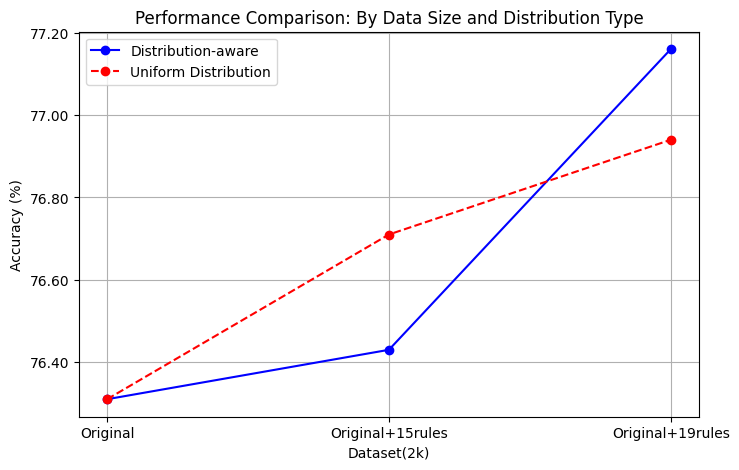

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 2천개
# 성능 데이터 정의
categories = ['Original', 'Original+15rules', 'Original+19rules']
performance_X = [76.31, 76.71, 76.94]  # 분포X의 성능
performance_O = [76.31, 76.43, 77.16]  # 분포O의 성능

# 꺾은선 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(categories, performance_O, marker='o', label='Distribution-aware', linestyle='-', color='blue')
plt.plot(categories, performance_X, marker='o', label='Uniform Distribution', linestyle='--', color='red')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset(2k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# y축 레이블 포맷 설정
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.show()


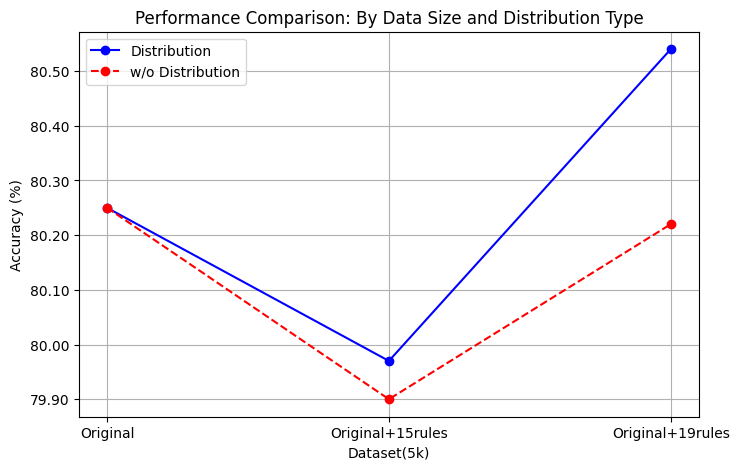

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 5천개
# 성능 데이터 정의
categories = ['Original', 'Original+15rules', 'Original+19rules']
performance_X = [80.25, 79.90, 80.22]  # 분포X의 성능
performance_O = [80.25, 79.97, 80.54]  # 분포O의 성능

# 꺾은선 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(categories, performance_O, marker='o', label='Distribution', linestyle='-', color='blue')
plt.plot(categories, performance_X, marker='o', label='w/o Distribution', linestyle='--', color='red')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset(5k)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# y축 레이블 포맷 설정
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.show()


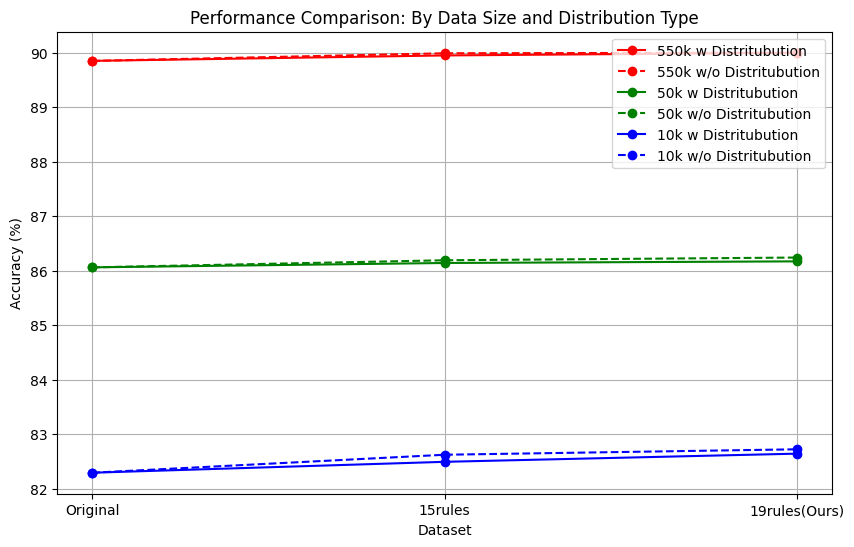

In [70]:
import matplotlib.pyplot as plt

# 성능 데이터 정의
categories = ['Original', '15rules', '19rules(Ours)']
performance_data = {
    '550k': {'w': [89.85, 89.95, 90.00], 'w/o': [89.85, 89.99, 90.00]},
    '50k': {'w': [86.06, 86.14, 86.17], 'w/o': [86.06, 86.19, 86.24]},
    '10k': {'w': [82.29, 82.49, 82.64], 'w/o': [82.29, 82.62, 82.72]}
}

# 전체 데이터 그리기
plt.figure(figsize=(10, 6))

# 각 데이터 크기와 분포 유형별 성능 플로팅
colors = {'550k': 'red', '50k': 'green', '10k': 'blue'}  # 데이터 크기별 색상
styles = {'w': '-', 'w/o': '--'}  # 분포 유형별 스타일

for data_size, performances in performance_data.items():
    for distribution, perf in performances.items():
        plt.plot(categories, perf, marker='o', linestyle=styles[distribution],
                 color=colors[data_size], label=f'{data_size} {distribution} Distritubution')

plt.title('Performance Comparison: By Data Size and Distribution Type')
plt.xlabel('Dataset')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()
